## Time Series and MCE Analysis of Heat Vulnerability Areas in Washington, DC

### Project Overview

The objective of the project is to develop a Heat Sensitivity Exposure Index (HSEI) using a Multi Criteria Evaluation (MCE) and time series change detection. This index will aim to assist in both the assessment of current extreme heat planning efforts and the forecasting of future heat sensitivity and exposure trends in major urban areas across the United States. 

This application aims to provide a fully automated open-source system that compiles, processes, analyzes, and displays the result index data for the city of Washington, DC. It will identify the most vulnerable census tracts based on environmental, socio-economic and demographic variables.

The entire project repository can be found on <a href="https://github.com/IANnappi577/GEOG3198_Final_Project">Github</a>

Refer to the project Terms of Reference (TOR), Pseudocode, and Data Sources documents for a complete breakdown of the workflow and steps taken to complete the work

### Data Dependencies

The `/data/` folder must be in the same directory as this Jupyter Notebook and must contain the following subdirectories: DC_Boundary_shapefile, demographic_data, final_cleaned_data, green_areas, tdmean, temperature_data, tigerline_shapefiles, and tmax

### List of Final Multicritera Analysis Variables

The following variables will be used toward the final Heat Sensitivity Exposure Index (HSEI):
- Number of Extreme Heat Days (> 90F / 32.2 C)
- Mean Dew Point Temperature Averaged Across Key Summer Months (May - September)
- Maximum Temperature Averaged Across Key Summer Months (May - September)
- Percentage of Small Children (< 5)
- Percentage of Elderly individuals (> 65)
- Percentage of Individuals with Disabilities or Chronic Health Issues
- Percentage of Individuals Below the Poverty Level
- Percentage Impervious Surface (Measure of the Percentage of Greenspace Area)


In [40]:
# Import required libraries
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from rasterstats import zonal_stats
import subprocess

# Define global variables for use
# An appropriate final projection was chosen for the census tracts for analysis, NAD83 / Maryland (EPSG:26985)
PROJECTION = 'EPSG:26985'

### Part 1: Downloading and Cleaning Data for Use

First, the variables for the MCE needed to be gathered from various locations and sources, cleaned, summarized, and clipped to the census tract boundaries for the study area. Each variable is cleaned in a seperate function below, where the functions are year-independent, meaning they are run once for each year in the time series (2015 and 2025).

Function List:
- `clean_extreme_heat_days()` -- Loads and cleans the variable: Number of Extreme Heat Days (days over 90 deg F or 32 deg Celsius)
- `clip_prisms_by_year()` -- Clips raw PRISM rasters, either for the variable tdmean or the variable tmax, to the study area and stacks them by month
- `average_zonal_stats_by_year()` -- Performs the mean across stacked, clipped PRISM rasters, either for the variable tdmean or the variable tmax, and computes zonal statistics to clip the values to census tract boundaries
- `process_demographics_data()` -- Computes MCE variables for all of the Census Bureau Demographics used in the MCE analysis, including percentage of young and elderly individuals, those with disabilities, and those under the poverty level.
- `clean_green_space_raster()` -- Cleans and computes zonal statistics on the percent impervious surface landcover rasters, assigning a mean percentage to each census tract

#### Clean the Variable: Number of Extreme Heat Days

Define a function to read the CSVs of weather stations with the variable we need, and summarize it to census tracts

In [41]:
def clean_extreme_heat_days(year: str):
    # load the raw CSV
    temp_csv = pd.read_csv(f'./data/temperature_data/{year}_temperature_raw.csv')

    # convert to a GeoDataFrame using the existing lat/long coords
    temp = gpd.GeoDataFrame(temp_csv, geometry=gpd.points_from_xy(temp_csv.LONGITUDE, temp_csv.LATITUDE), crs='EPSG:4326')

    # drop unnecessary columns, which differ whether this is the 2015 or 2025 data:
    if(year == '2015'):
        temp.drop(columns=['LATITUDE', 'LONGITUDE', 'AWND', 'WSFG', 'DX70', 'TMAX', 'TAVG', 'EMXT'], inplace=True)
    else:
        temp.drop(columns=['LATITUDE', 'LONGITUDE', 'DX70', 'TMAX', 'TAVG', 'EMXT'], inplace=True)

    # Remove the weather stations that do not have the variable that we need: Number of Max Heat days, or DX90
    # i.e., we will remove the weather stations for which DX90 is null
    temp = temp[temp['DX90'].notna()]

    # reproject to the final projection
    temp.to_crs(PROJECTION, inplace=True)

    # Load the census tracts
    census_bounds = gpd.read_file(f'./data/tigerline_shapefiles/tigerline_{year}_tract/tl_{year}_11_tract.shp')
    # Reproject the census tracts
    census_bounds.to_crs(PROJECTION, inplace=True)

    # Now for each polygon in the census tract shapefile, we want to find the closest point (weather station) 
    # and assign the DX90 value from that point to that census tract.
    # We will use a form of sjoin called sjoin_nearest, which will find the closest polygon per point.
    
    # Here is a tutorial I followed to understand the syntax for a similar task:
    # https://stackoverflow.com/questions/72639523/question-on-geopandas-spatial-join-nearest
    joined_points_polygons = gpd.sjoin_nearest(
        census_bounds, # polygon geometry
        temp, # point geometry
        how='left',
        # we will leave out 'max_distance' from the tutorial
        distance_col="distances"  # I suppose this is a column for the min distance it found between polygon/point
    )
    
    # Visualize the final important columns
    print(f'--------- {year} ---------')
    print(joined_points_polygons.head(2))

    # Export to GeoJSON
    joined_points_polygons.to_file(f'./data/temperature_data/{year}_extemp_census_tract.geojson')

#####################################
# Run the above function for both years
clean_extreme_heat_days('2015')
clean_extreme_heat_days('2025')

--------- 2015 ---------
  STATEFP COUNTYFP TRACTCE        GEOID NAME_left            NAMELSAD  MTFCC  \
0      11      001  010900  11001010900       109    Census Tract 109  G5020   
1      11      001  009906  11001009906     99.06  Census Tract 99.06  G5020   

  FUNCSTAT    ALAND   AWATER     INTPTLAT      INTPTLON  \
0        S  2379832  2936613  +38.8132450  -077.0238468   
1        S   252684        0  +38.8879464  -076.9359151   

                                            geometry  index_right  \
0  POLYGON ((396595.679 125860.383, 396600.993 12...            6   
1  POLYGON ((405157.634 135415.257, 405157.719 13...           35   

       STATION                    NAME_right  ELEVATION  DATE  DX90  \
0  USC00186800              OXON HILL, MD US       57.9  2015  25.0   
1  USC00186350  NATIONAL ARBORETUM DC, MD US       15.2  2015  48.0   

     distances  
0  2409.928172  
1  3803.046335  
--------- 2025 ---------
  STATEFP COUNTYFP TRACTCE        GEOID               GEOI

#### Clean the Variables: Mean Dew Point Temp (tdmean) and Maximum Temp (tmax) Averaged Across Key Summer Months

These two variables were consolidated into one function because they follow the same workflow. Two seperate steps were performed:
1. First, the PRISM data .tif's were loaded, stacked by month from May to September, and then clipped to the study area, the bounds of DC.
2. Then, an average of the variable was performed across all time series month bands to get an average over all months. Zonal statistics were then performed to summarize the variable per tigerline census tract polygon

These steps were carried out in the following 2 functions: 1) clip_prisms_by_year() and 2) average_zonal_stats_by_year()

Finally, visualize_PRISM_data() displays the final rasters and summarized zonal statistics in a matplotlib map

In [42]:
def clip_prisms_by_year(year: str, variable: str):

    # Load DC boundaries
    dc_bounds = gpd.read_file('./data/DC_Boundary_shapefile/DC_Boundary.shp')

    # find all month bands using glob
    all_months = sorted(glob(f'./data/{variable}/{year}/prism_{variable}_us*.tif'))
    print('found', len(all_months), f'bands for {year}')

    # stack all bands into one mega 5-band file

    # read the profile from the first band and copy + update the profile
    with rasterio.open(all_months[0]) as src0:
        stacked_profile = src0.profile.copy()

    # update profile
    stacked_profile.update({
        'count': len(all_months)
    })

    # stack bands into a master file with all bands from each month
    print(f'stacking {year} rasters')
    with rasterio.open(f'./data/{variable}/{year}/{variable}_months_stacked_{year}.tif', 'w', **stacked_profile) as dst:
        for band_num, filename in enumerate(all_months, start=1):
            with rasterio.open(filename) as src:
                dst.write(src.read(1), band_num)

    # now clip the stacked 5-band file to the DC boundaries
    print(f'clipping {year} rasters to DC boundaries')
    with rasterio.open(f'./data/{variable}/{year}/{variable}_months_stacked_{year}.tif') as src:
        # First reproject the DC bounds to the CRS of the rasters
        dc_bounds.to_crs(src.profile['crs'], inplace=True)

        # Clip using the dc boundaries as a cookie cutter
        # Guide to using mask() on a raster:
        # https://gis.stackexchange.com/questions/444062/clipping-raster-geotiff-with-a-vector-shapefile-in-python
        out_image, out_transform = mask(src, dc_bounds.geometry, crop=True)
        clipped_profile = src.meta.copy()
        
    # Update the profile of the new clipped raster, following the instructions in the above GIS stackexchange link
    clipped_profile.update({
        'driver': 'Gtiff',
        'height': out_image.shape[1],
        'width': out_image.shape[2],
        'transform': out_transform
    })
    
    # write to the final clipped output file
    with rasterio.open(f'./data/{variable}/{year}/{variable}_months_stacked_clipped_{year}.tif', 'w', **clipped_profile) as dst:
        dst.write(out_image)

In [43]:
def average_zonal_stats_by_year(year: str, variable: str):
    # Load census tract boundaries
    census_bounds = gpd.read_file(f'./data/tigerline_shapefiles/tigerline_{year}_tract/tl_{year}_11_tract.shp')

    # Compute the average across all month bands to get the average per month

    # Load the stacked, clipped raster
    with rasterio.open(f'./data/{variable}/{year}/{variable}_months_stacked_clipped_{year}.tif') as src:
        # temporarily reproject the census tracts to the CRS of the raster
        census_bounds.to_crs(src.profile['crs'], inplace=True)
        
        # read all of the bands
        all_months = src.read()

        # replace the nodata value (-9999) to np.nan
        all_months = all_months.astype(np.float32)
        all_months[all_months == -9999] = np.nan

        # Compute the average across all of the bands to collapse down to a single-band raster
        avg_across_months = np.nanmean(all_months, axis=0)

        # write the result to an output file
        avg_profile = src.profile.copy()
        avg_profile.update({
            'count': 1,  # now we only habe 1 band
            'nodata': np.nan,  # since avg is a float we need to store this as a float now
            'dtype': 'float32' # data type is now float
        })

        with rasterio.open(f'./data/{variable}/{year}/{variable}_averaged.tif', 'w', **avg_profile) as dst:
            dst.write(avg_across_months, 1)

    # Compute the mean for each census tract using zonal_stats()
    # Since the pixels are so large, all_touched here will make a difference in the result. We'll
    # choose all_touched=True because the large pixels near the edge should NOT be excluded to calculate a more
    # accurate mean
    mean_per_census_tract = zonal_stats(
        vectors=census_bounds,
        raster=f'./data/{variable}/{year}/{variable}_averaged.tif',
        nodata=np.nan,
        stats=['mean'],
        all_touched=True
    )
    # Convert to a pandas DataFrame
    mean_per_census_tract = pd.DataFrame(mean_per_census_tract)

    # Create a copy of the census tract boundaries that will serve as the main dataframe 
    # for final summarized statistics
    summarized_stats = census_bounds.copy()
    summarized_stats.drop(columns=['NAMELSAD', 'MTFCC', 'FUNCSTAT', 'STATEFP', 'COUNTYFP', 'INTPTLAT', 'INTPTLON'], inplace=True)

    # Add the mean to the summary dataframe (summarized_stats)
    summarized_stats[f'mean_{variable}_{year}'] = mean_per_census_tract['mean']

    # Reproject and export the final statistics file
    summarized_stats.to_crs(PROJECTION, inplace=True)
    summarized_stats.to_file(f'./data/{variable}/{year}/summary_statistics_{year}.geojson')

In [44]:
# Create a function to visualize the results for each variable product with a nice matplotlib map
def visualize_PRISM_data(variable: str):
    
    # Load data
    with rasterio.open(f'./data/{variable}/2015/{variable}_averaged.tif') as src:
        prism_data_2015 = src.read(1)

    with rasterio.open(f'./data/{variable}/2025/{variable}_averaged.tif') as src:
        prism_data_2025 = src.read(1)

    summarized_stats_2015 = gpd.read_file(f'./data/{variable}/2015/summary_statistics_2015.geojson')
    summarized_stats_2025 = gpd.read_file(f'./data/{variable}/2025/summary_statistics_2025.geojson')

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

    # raster visualizations
    im1 = ax1.imshow(prism_data_2015, cmap='Greens')
    ax1.set_title(f'2015 {variable}')
    plt.colorbar(im1, ax=ax1)

    im2 = ax2.imshow(prism_data_2025, cmap='Greens')
    ax2.set_title(f'2025 {variable}')
    plt.colorbar(im2, ax=ax2)

    # summary/mean values visualization
    summarized_stats_2015.plot(column=f'mean_{variable}_2015', scheme='quantiles', k=5, cmap='YlOrRd', legend=True,
        legend_kwds={'loc': 'lower left', 'title': f'mean {variable}'}, linewidth=0.5, ax=ax3, edgecolor='black',
        missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
    )
    ax3.set_title(f'mean {variable} per census tract 2015')
    ax3.axis('off')

    summarized_stats_2025.plot(column=f'mean_{variable}_2025', scheme='quantiles', k=5, cmap='YlOrRd', legend=True,
        legend_kwds={'loc': 'lower left', 'title': f'mean {variable}'}, linewidth=0.5, ax=ax4, edgecolor='black',
        missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
    )
    ax4.set_title(f'mean {variable} per census tract 2025')
    ax4.axis('off')

    plt.tight_layout()
    plt.show()

found 5 bands for 2015
stacking 2015 rasters
clipping 2015 rasters to DC boundaries


/var/folders/j7/dmy_q6xs6bq6rpt0zww_fn4m0000gn/T/ipykernel_35022/129741251.py:20: RuntimeWarning: Mean of empty slice
  avg_across_months = np.nanmean(all_months, axis=0)


found 5 bands for 2025
stacking 2025 rasters
clipping 2025 rasters to DC boundaries


/var/folders/j7/dmy_q6xs6bq6rpt0zww_fn4m0000gn/T/ipykernel_35022/129741251.py:20: RuntimeWarning: Mean of empty slice
  avg_across_months = np.nanmean(all_months, axis=0)


found 5 bands for 2015
stacking 2015 rasters
clipping 2015 rasters to DC boundaries


/var/folders/j7/dmy_q6xs6bq6rpt0zww_fn4m0000gn/T/ipykernel_35022/129741251.py:20: RuntimeWarning: Mean of empty slice
  avg_across_months = np.nanmean(all_months, axis=0)


found 5 bands for 2025
stacking 2025 rasters
clipping 2025 rasters to DC boundaries


/var/folders/j7/dmy_q6xs6bq6rpt0zww_fn4m0000gn/T/ipykernel_35022/129741251.py:20: RuntimeWarning: Mean of empty slice
  avg_across_months = np.nanmean(all_months, axis=0)


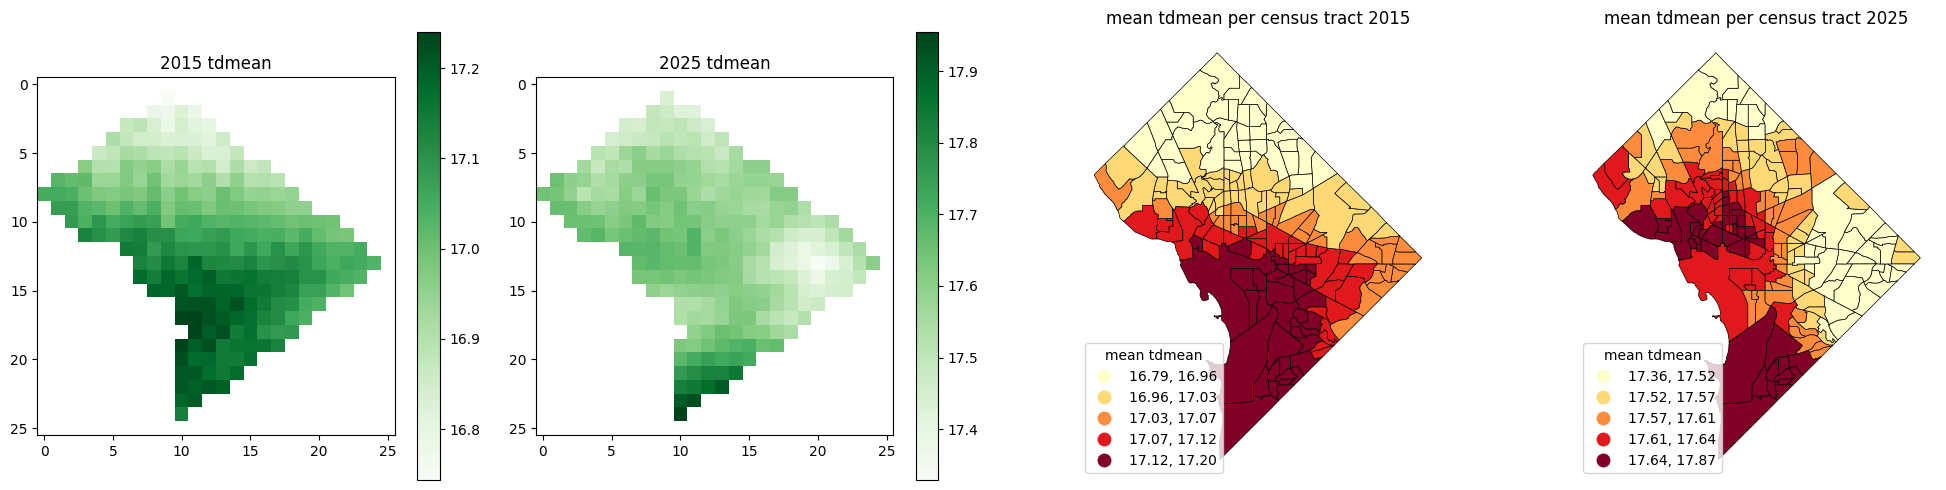

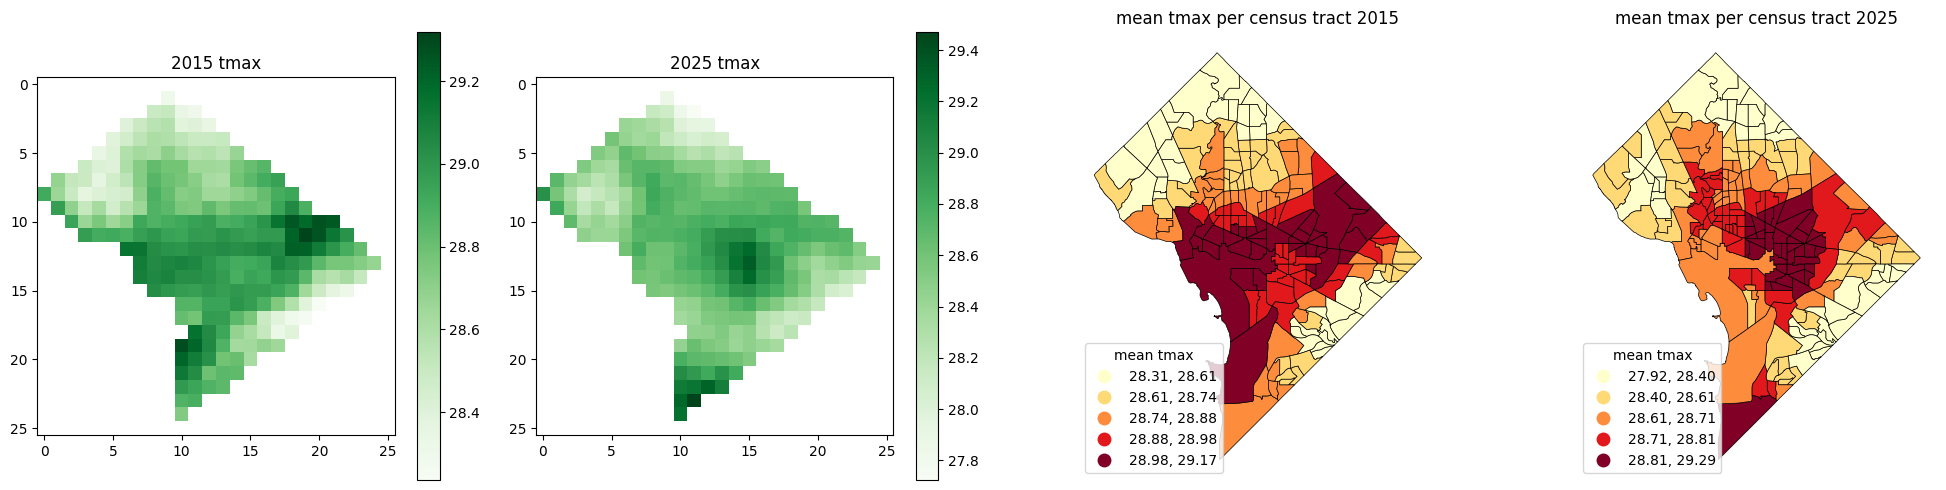

In [45]:
#####################################
# Run the above function for both years and both variables

# tdmean
clip_prisms_by_year('2015', 'tdmean')
average_zonal_stats_by_year('2015', 'tdmean')
clip_prisms_by_year('2025', 'tdmean')
average_zonal_stats_by_year('2025', 'tdmean')

# tmax
clip_prisms_by_year('2015', 'tmax')
average_zonal_stats_by_year('2015', 'tmax')
clip_prisms_by_year('2025', 'tmax')
average_zonal_stats_by_year('2025', 'tmax')

# visualize the results
visualize_PRISM_data('tdmean')
visualize_PRISM_data('tmax')

#### Clean the Variables: Census Bureau Demographic Statistics

This function will compute various statistics from common Census Bureau tables, including the following MCE variables:
- Percentage of Small Children < 5
- Percentage of Elderly individuals > 65
- Percentage of Individuals with Disabilities
- Percentage of Individuals Below the Poverty Level

In [46]:
def process_demographics_data(year: str):
    
    # Load all the raw census tables
    tot_pop = pd.read_csv(f'./data/demographic_data/raw_tables/{year}_B01003.csv')
    disability_poverty = pd.read_csv(f'./data/demographic_data/raw_tables/{year}_B17020_B18101.csv')

    # Load the tigerline census tracts
    census_bounds = gpd.read_file(f'./data/tigerline_shapefiles/tigerline_{year}_tract/tl_{year}_11_tract.shp')
    # Reproject to the final projection
    census_bounds.to_crs(PROJECTION, inplace=True)

    # Drop the unnecessary columns (blank or unneeded)
    cols = ['GISJOIN', 'STUSAB', 'REGIONA', 'DIVISIONA', 'STATE', 'STATEA', 'COUNTY', 'COUNTYA',
        'COUSUBA', 'PLACEA', 'TRACTA', 'CONCITA', 'AIANHHA', 'RES_ONLYA', 'TRUSTA', 'AIHHTLI', 
        'ANRCA', 'CBSAA', 'CSAA', 'METDIVA', 'UAA', 'CDCURRA', 'SLDUA', 'SLDLA', 'ZCTA5A', 'SUBMCDA',
        'SDELMA', 'SDSECA', 'SDUNIA', 'PCI', 'PUMAA', 'BTTRA', 'NAME_E', 'NAME_M']
    disability_poverty.drop(columns=cols, inplace=True)
    tot_pop.drop(columns=cols, inplace=True)
    
    # Drop columns NOT found in disability_poverty
    tot_pop.drop(columns=['BLKGRPA', 'BTBGA'], inplace=True)

    # drop columns specific to 2015 data
    if(year == '2015'):
        extra_cols = ['AITSCEA', 'NECTAA', 'CNECTAA', 'NECTADIVA']
        disability_poverty.drop(columns=extra_cols, inplace=True)
        tot_pop.drop(columns=extra_cols, inplace=True)

    # drop columns specific to 2025 data
    if(year == '2025'):
        disability_poverty.drop(columns=['AITSA'], inplace=True)
        tot_pop.drop(columns=['AITSA'], inplace=True)

    # Clean the GEOID that can be joined to the census tracts
    # This value is different for 2015 and 2025, of course, cause the census bureau likes changing
    # things between years.
    if(year == '2015'):
        # For 2015, we need to convert the GEOID column into one compatible with the Tigerline shapefile GEOID
        # Simple drop the prefix '14000US' from the GEOID column
        tot_pop['GEOID_JOIN'] = [geoid[7:] for geoid in tot_pop['GEOID']]
        disability_poverty['GEOID_JOIN'] = [geoid[7:] for geoid in disability_poverty['GEOID']]
        # also drop the old confusing 'GEOID' column in these so it doesn't cause problems while merging
        tot_pop.drop(columns=['GEOID'], inplace=True)
        disability_poverty.drop(columns=['GEOID'], inplace=True)
    else:
        # For 2025, we simply need to rename the TL_GEO_ID to be the GEOID_JOIN column to join on
        tot_pop.rename(columns={'TL_GEO_ID': 'GEOID_JOIN'}, inplace=True)
        disability_poverty.rename(columns={'TL_GEO_ID': 'GEOID_JOIN'}, inplace=True)
        # Also change this column to a string, as it is currently an int64 and cannot be joined to the string GEOID:
        tot_pop['GEOID_JOIN'] = tot_pop['GEOID_JOIN'].astype(str)
        disability_poverty['GEOID_JOIN'] = disability_poverty['GEOID_JOIN'].astype(str)

    # Join both tables to the census tracts
    dem_stats = pd.merge(census_bounds, tot_pop, how='inner', left_on='GEOID', right_on='GEOID_JOIN')
    # drop some columns that will be duplicated when we join the second table
    dem_stats.drop(columns=['GEOID_JOIN', 'YEAR'], inplace=True)
    # join second table
    dem_stats = pd.merge(dem_stats, disability_poverty, how='inner', left_on='GEOID', right_on='GEOID_JOIN')

    # Now calculate the variables we want and put them in appropriatly-named columns

    # The census bureau official column names follow a pre-determined pattern, where a 4-character prefix representing 
    # the year is followed by the variable number code ('E' + a 3-digit number). Although the prefix differs by year, the 
    # variable codes are the same, so we will dynamically build the column names per year. So, we define the prefix for each 
    # year, and will substitute this to form the complete column name:
    if(year == '2015'):
        prefix = 'AD2S'
    else:
        prefix = 'AU9J'

    # When fetching and computing each of the variables below, each column is normalized by the total population
    # column, either AD2SE001 for 2015 and AU9JE001 for 2025.
    # See the Data Sources document or the official codebooks in ./data/demographic_data/raw_tables/ to see what each 
    # column code means.

    # Finally, each final value is a decimal percentage, so to get the percentage on a scale from 0-100,
    # simply multiply by 100

    # ------------
    # Percentage of Individuals under the age of 5
    #       --> Sum the number of male and female individuals < 5
    dem_stats['Perc_un_5'] = (dem_stats[prefix + 'E003'] + dem_stats[prefix + 'E022']) / dem_stats[prefix + 'E001']

    # ------------
    # Percentage of Elderly Individuals over 65
    #       --> Sum the number of male and female individuals in the 65-74 and 75+ categories
    dem_stats['Perc_ov_65'] = (dem_stats[prefix + 'E015'] + dem_stats[prefix + 'E018'] +
                                dem_stats[prefix + 'E034'] + dem_stats[prefix + 'E037']) / dem_stats[prefix + 'E001']

    # ------------
    # Percentage of Individuals with a Disability
    #       --> Sum the number of male and female individuals with a disability in every age category                                 
    dem_stats['Perc_disabl'] = (dem_stats[prefix + 'E004'] + dem_stats[prefix + 'E007'] +
                                dem_stats[prefix + 'E010'] + dem_stats[prefix + 'E013'] +
                                dem_stats[prefix + 'E016'] + dem_stats[prefix + 'E019'] +
                                dem_stats[prefix + 'E023'] + dem_stats[prefix + 'E026'] +
                                dem_stats[prefix + 'E029'] + dem_stats[prefix + 'E032'] +
                                dem_stats[prefix + 'E035'] + dem_stats[prefix + 'E038']) / dem_stats[prefix + 'E001']

    # Now the other table (For poverty statistics) has a different prefix for 2015 and 2025, so update the prefix:
    if(year == '2015'):
        prefix = 'AD2D'
    else:
        prefix = 'AU84'

    # ------------
    # Percentage of Individuals Below the Poverty Level
    #       --> Simply total number of individuals under the poverty level, normalized by the number of
    #               people in this survey
    dem_stats['Perc_in_pov'] = dem_stats[prefix + 'E002'] / dem_stats[prefix + 'E001']

    # Remove the unneeded columns and only keep the columns we calculated for export
    final_statistics = dem_stats[['GEOID', 'NAME', 'ALAND', 'AWATER', 'Perc_un_5', 'Perc_ov_65', 
                    'Perc_disabl', 'Perc_in_pov', 'geometry']].copy()
    
    # Visualize the final statistics
    print(final_statistics.head(5))

    # Export the final geojson
    final_statistics.to_file(f'./data/demographic_data/final_tables/{year}_final_stats.geojson')

In [47]:
#####################################
# Run the above function for both years
print('-------- 2015 demographics --------')
process_demographics_data('2015')
print()

print('-------- 2025 demographics --------')
process_demographics_data('2025')

-------- 2015 demographics --------
         GEOID   NAME    ALAND   AWATER  Perc_un_5  Perc_ov_65  Perc_disabl  \
0  11001010900    109  2379832  2936613   0.119298    0.038363     0.207485   
1  11001009906  99.06   252684        0   0.017751    0.134122     0.159763   
2  11001009905  99.05   431557        0   0.088721    0.063578     0.114943   
3  11001010400    104  2740208       83   0.091743    0.076292     0.157412   
4  11001009903  99.03   383679        0   0.040154    0.095160     0.179868   

   Perc_in_pov                                           geometry  
0     0.486646  POLYGON ((396595.679 125860.383, 396600.993 12...  
1     0.269560  POLYGON ((405157.634 135415.257, 405157.719 13...  
2     0.269203  POLYGON ((406132.535 134772.884, 406138.753 13...  
3     0.313375  POLYGON ((399202.057 130154.314, 399205.187 13...  
4     0.177243  POLYGON ((406068.252 135777.566, 406249.399 13...  

-------- 2025 demographics --------
         GEOID    NAME    ALAND  AWATER  Per

#### Clean the Variable: The Percentage Impervious Surface (Measure of Percentage of Greenspace Area)

This function will load and summarize rasters representing the percentage impervious surface at any given area in DC, and visualize the results.

In [48]:
def clean_green_space_raster(year: str):
    # Load census tract boundaries
    # Change the year to 2025 if we are processing the 2024 raster:
    if(year == '2024'):
        census_year = '2025'
    else:
        census_year = '2015'
    census_bounds = gpd.read_file(f'./data/tigerline_shapefiles/tigerline_{census_year}_tract/tl_{census_year}_11_tract.shp')

    # Load the percent impervious raster
    with rasterio.open(f'./data/green_areas/NLCD_{year}/Annual_NLCD_Fractional_Impervious_{year}.tiff') as src:

        # reproject the census tracts to the CRS of the raster (custom PROJCS projection)
        census_bounds.to_crs(src.profile['crs'], inplace=True)

        # read the first band (there is only 1 band) and convert nodata values to np.nan
        perc_impervious = src.read(1)
        perc_impervious = perc_impervious.astype(np.float32)
        # the nodata value in our case is 250 (unsigned 8-bit int)
        perc_impervious[perc_impervious == src.profile['nodata']] = np.nan

        # use zonal_stats() to summarize the percent impervious surface per census tract
        # Since the resolution on this raster is much higher than the PRISM data, we can
        # use all_touched=False and still get accurate means
        mean_per_census_tract = zonal_stats(
            vectors=census_bounds,
            raster=perc_impervious,
            nodata=np.nan,
            stats=['mean'],
            affine=src.profile['transform'],
            all_touched=True
        )
        # Convert to a pandas DataFrame
        mean_per_census_tract = pd.DataFrame(mean_per_census_tract)

        # Add the mean to the census tracts dataframe
        census_bounds[f'mean_imperv_{year}'] = mean_per_census_tract['mean']

    # reproject to the target CRS and export the census tract bounds with the new column
    census_bounds.to_crs(PROJECTION, inplace=True)
    census_bounds.to_file(f'./data/green_areas/NLCD_{year}/census_imperv_surface_{year}.geojson')

    # visualize the results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(perc_impervious, cmap='Greens')
    ax1.set_title(f'{year} percent impervious surface')
    plt.colorbar(im1, ax=ax1)

    census_bounds.plot(column=f'mean_imperv_{year}', scheme='natural_breaks', k=5, cmap='YlOrRd', legend=True,
        legend_kwds={'loc': 'lower left', 'title': f'Percent Impervious Surface'}, linewidth=0.5, ax=ax2, edgecolor='black',
        missing_kwds={'color': 'lightgrey', 'label': 'No Data'}
    )
    ax2.set_title(f'Mean Percent Impervious Surface per Census Tract {year}')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

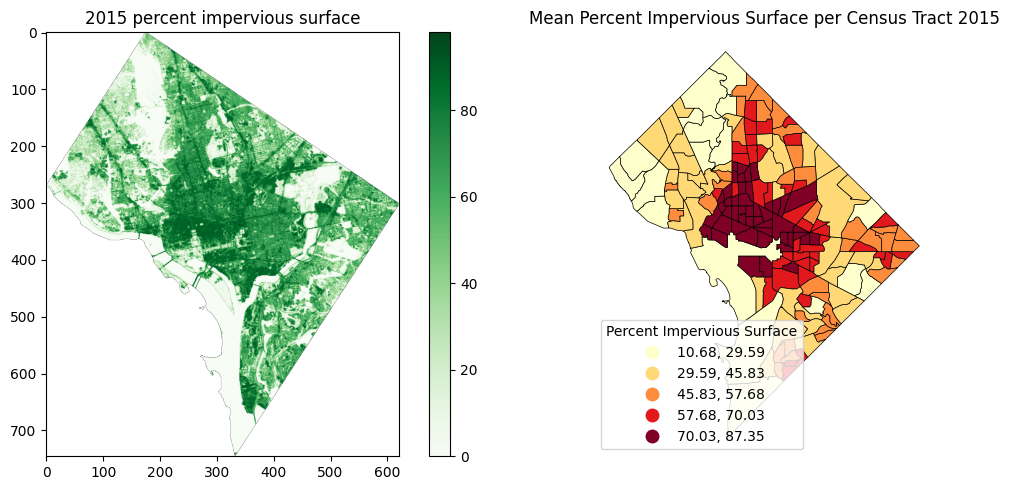

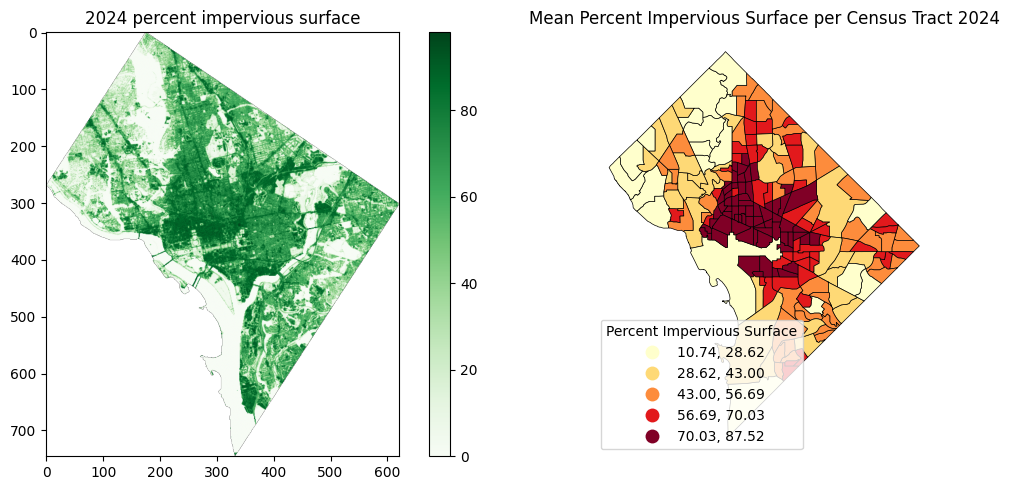

In [49]:
#####################################
# Run the above function for both years
clean_green_space_raster('2015')
clean_green_space_raster('2024')

#### Combine All Variables into a Final Statistics File

All variables are in seperate .geojson files per census tract. Pull and merge all of them, dropping unnecessary columns

Final Dataframe Column Names and Descriptions:
```
- DX90               --> number of extreme heat days > 90 deg
- distances          --> the distance from each census tract to the weather station that produced DX90.
- mean_imperv_{year} --> NOTE: the year is 2024 for the later one, not 2025
- Perc_un_5          --> Percent of the population under 5 yrs old, in decimal percent from 0-1
- Perc_ov_65         --> Percent of the population over 65 yrs old, in decimal percent from 0-1
- Perc_disabl        --> Percent of the population that is disabled, in decimal percent from 0-1
- Perc_in_pov        --> Percent of the population under the poverty line, in decimal percent from 0-1
- mean_tdmean_{year} --> The average dew point over the months May - September
- mean_tmax_{year}   --> The average maximum temperature over the months May - September
```

...Where each {year} here is either 2015 or 2025 (or 2024, for Impervious Surface rasters)

In [50]:
def combine_variables(year: str):
    # Load all the variables
    
    ##########################
    # Number of Extreme Temperature Days
    ex_temp = gpd.read_file(f'./data/temperature_data/{year}_extemp_census_tract.geojson')

    ##########################
    # Percent Impervious Surface
    if(year == '2025'):
        census_year = '2024'
    else:
        census_year = '2015'
    green_areas = gpd.read_file(f'./data/green_areas/NLCD_{census_year}/census_imperv_surface_{census_year}.geojson')

    ##########################
    # Demographics Data
    demographics = gpd.read_file(f'./data/demographic_data/final_tables/{year}_final_stats.geojson')

    ##########################
    # PRISM data / tdmean - mean dew point
    tdmean = gpd.read_file(f'./data/tdmean/{year}/summary_statistics_{year}.geojson')

    ##########################
    # PRISM data / tmax - maximum average temperature
    tmax = gpd.read_file(f'./data/tmax/{year}/summary_statistics_{year}.geojson')

    # Join everything to the ex_temp dataframe
    # Drop all columns other than the GEOID, which will be used to join on every other dataframe
    green_areas = green_areas[['GEOID', f'mean_imperv_{census_year}']].copy()
    demographics = demographics[['GEOID', 'Perc_un_5', 'Perc_ov_65', 'Perc_disabl', 'Perc_in_pov']].copy()
    tdmean = tdmean[['GEOID', f'mean_tdmean_{year}']].copy()
    tmax = tmax[['GEOID', f'mean_tmax_{year}']].copy()

    # Merge all dataframes to the ex_temp dataframe using the GEOID
    final_statistics = pd.merge(ex_temp, green_areas, how='inner', left_on='GEOID', right_on='GEOID')
    final_statistics = pd.merge(final_statistics, demographics, how='inner', left_on='GEOID', right_on='GEOID')
    final_statistics = pd.merge(final_statistics, tdmean, how='inner', left_on='GEOID', right_on='GEOID')
    final_statistics = pd.merge(final_statistics, tmax, how='inner', left_on='GEOID', right_on='GEOID')

    # Drop last unnecessary columns
    final_statistics = final_statistics[['GEOID', 'DX90', 'distances', f'mean_imperv_{census_year}', 'Perc_un_5',
            'Perc_ov_65', 'Perc_disabl', 'Perc_in_pov', f'mean_tdmean_{year}', f'mean_tmax_{year}', 'geometry']].copy()

    # Export to final geojson
    final_statistics.to_file(f'./data/final_cleaned_data/{year}_final_cleaned_dataframe.geojson')
    print(f'Success! Exported the final {year} statistics file')

In [51]:
#####################################
# Run the above function for both years
combine_variables('2015')
combine_variables('2025')

Success! Exported the final 2015 statistics file
Success! Exported the final 2025 statistics file


### Part 2: Perform the MCE analysis on the Census Tracts

Notes for the steps here:
- We will need to convert tdmean to humidity. It can simply be higher dew point = higher humidity, because that is usually the case when the airtemp is hotter than the dewpoint (in a technical sense, the humidity is highest when the dew point approaches the actual air temperature)
- Do not weigh the # of extreme heat days very highly, because there only turned out to be 1 or 2 unique values across the entirety of DC because there were not enough nearby weather stations that had that data :(